# 11 — LSEG non-pooled robustness and publisher weighting

The LSEG regimes are never pooled with FNSPID or with one another.
Sector-33 tests unweighted, Reuters-only, non-Reuters, ex-ante Reuters-2×,
and actionable-only scores on the same news-bearing company-days. Midcap-22 is a separate
Reuters-only arm. The target is raw open-to-next-open return because a matched
market benchmark is unavailable in these local LSEG panels.

Inference is mean daily cross-sectional Spearman IC with HAC(5). BH is applied
within the five-arm sector-33 family. These 2025–2026 samples are robustness
snapshots, not additional chronological evaluation data for FNSPID.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.lseg_robustness import (  # noqa: E402
    SECTOR_FAMILY,
    attach_next_open_returns,
    attach_weighted_signals,
    lseg_ic_table,
    publisher_table,
)

OUTPUT = REPO_ROOT / "final_experiments" / "outputs" / "11_lseg_robustness"
OUTPUT.mkdir(parents=True, exist_ok=True)

SECTOR_ROOT = REPO_ROOT / "Data" / "collections" / "lseg_us_sector_33_6m" / "derived" / "headline_value_analysis_lseg_priced"
MIDCAP_ROOT = REPO_ROOT / "Data" / "collections" / "lseg_us_midcap_22_1y" / "derived" / "content_quality_all"
SECTOR_PRICES = REPO_ROOT / "Data" / "derived" / "prices" / "lseg_us_sector_33_strategy_adjusted_open.csv"
MIDCAP_PRICES = REPO_ROOT / "Data" / "derived" / "prices" / "lseg_us_midcap_22_strategy_adjusted_open.csv"

print("regimes: LSEG sector-33 and midcap-22, analysed separately")
print("target: raw next-open return; date-only news maps strictly after")
print("eligibility: headline_count > 0; identical firm-days within each regime")
print("inference: daily cross-sectional IC, HAC(5)")
print("sector family:", SECTOR_FAMILY)

regimes: LSEG sector-33 and midcap-22, analysed separately
target: raw next-open return; date-only news maps strictly after
eligibility: headline_count > 0; identical firm-days within each regime
inference: daily cross-sectional IC, HAC(5)
sector family: five LSEG sector-33 source/actionability arms x h1; BH-FDR q=0.05


## Publisher/source inventory and ex-ante tiers

In [2]:
sector_events = pd.read_csv(SECTOR_ROOT / "headline_events.csv")
sources = publisher_table(sector_events)
sources.to_csv(OUTPUT / "sector33_publisher_table.csv", index=False)

tiers = pd.DataFrame(
    [
        {
            "tier": "primary_wire",
            "source_rule": "source_codes == NS:RTRS",
            "weight": 2.0,
            "criterion": "Reuters identity declared before return analysis",
        },
        {
            "tier": "other_unresolved",
            "source_rule": "source_codes != NS:RTRS",
            "weight": 1.0,
            "criterion": "opaque source codes; no unsupported prestige classification",
        },
    ]
)
tiers.to_csv(OUTPUT / "publisher_tiers.csv", index=False)
display(sources.head(20))
display(tiers)

,source_codes,event_rows,unique_firm_headline_pairs,symbols,firm_days,mean_abs_score
6010,NS:GLORDP,90257,90257,33,4884,0.192293
9541,NS:X,57998,57998,33,4209,0.077484
5039,NS:EDG,29740,29740,33,1516,0.000134
8707,NS:RTRS,27659,27659,33,3364,0.101861
8093,NS:NEWNYS,21172,21172,30,3320,0.160086
3813,NS:CNBSTR,20394,20394,32,3952,0.176490
8119,NS:NEWWIR,13764,13764,33,1544,0.031749
8931,NS:SPONEW,13004,13004,6,128,0.041218
8183,NS:NOTENG,11810,11810,32,1878,0.036890
8461,NS:PLUPAT,11514,11514,29,2098,0.002750


,tier,source_rule,weight,criterion
0,primary_wire,source_codes == NS:RTRS,2.0,Reuters identity declared before return analysis
1,other_unresolved,source_codes != NS:RTRS,1.0,opaque source codes; no unsupported prestige c...


## Sector-33 source weighting comparison

In [3]:
sector_panel = attach_weighted_signals(pd.read_csv(SECTOR_ROOT / "company_day_panel.csv"))
sector = attach_next_open_returns(sector_panel, pd.read_csv(SECTOR_PRICES))
sector_results = lseg_ic_table(sector)
sector_results.to_csv(OUTPUT / "sector33_source_weighting_ic.csv", index=False)
display(sector_results.round(6))

,arm,n,n_clusters,n_dates_total,min_names,hac_lags,inference,ic,se,t,p,bh_reject_q05,multiplicity_family,target,eligibility
0,mean_sentiment_score,5985,124,124,3,5,mean_daily_cross_sectional_spearman_hac,-0.001473,0.016591,-0.088793,0.929246,False,five LSEG sector-33 source/actionability arms ...,raw open-to-next-open return; LSEG robustness ...,headline_count > 0 on identical firm-days
1,mean_reuters_sentiment_score,5985,124,124,3,5,mean_daily_cross_sectional_spearman_hac,0.002330,0.017803,0.130887,0.895865,False,five LSEG sector-33 source/actionability arms ...,raw open-to-next-open return; LSEG robustness ...,headline_count > 0 on identical firm-days
2,mean_non_reuters_sentiment_score,5985,124,124,3,5,mean_daily_cross_sectional_spearman_hac,-0.001995,0.016387,-0.121743,0.903102,False,five LSEG sector-33 source/actionability arms ...,raw open-to-next-open return; LSEG robustness ...,headline_count > 0 on identical firm-days
3,reuters_2x_weighted_score,5985,124,124,3,5,mean_daily_cross_sectional_spearman_hac,0.001528,0.016121,0.094808,0.924467,False,five LSEG sector-33 source/actionability arms ...,raw open-to-next-open return; LSEG robustness ...,headline_count > 0 on identical firm-days
4,mean_actionable_sentiment_score,5985,124,124,3,5,mean_daily_cross_sectional_spearman_hac,-0.031802,0.016920,-1.879605,0.060162,False,five LSEG sector-33 source/actionability arms ...,raw open-to-next-open return; LSEG robustness ...,headline_count > 0 on identical firm-days


## Midcap-22 Reuters-only robustness

Every event in this collection is Reuters, so Reuters weighting is undefined:
multiplying every observation by the same constant cannot change an average.
The comparison is ordinary mean versus the existing actionable-only filter.

,arm,n,n_clusters,n_dates_total,min_names,hac_lags,inference,ic,se,t,p,bh_reject_q05,multiplicity_family,target,eligibility
0,mean_sentiment_score,1053,177,242,3,5,mean_daily_cross_sectional_spearman_hac,0.004809,0.040536,0.118626,0.905571,False,two midcap-22 Reuters-only arms x h1; BH-FDR q...,raw open-to-next-open return; LSEG robustness ...,headline_count > 0 on identical firm-days
1,mean_actionable_sentiment_score,1053,175,242,3,5,mean_daily_cross_sectional_spearman_hac,0.000641,0.041270,0.015520,0.987617,False,two midcap-22 Reuters-only arms x h1; BH-FDR q...,raw open-to-next-open return; LSEG robustness ...,headline_count > 0 on identical firm-days


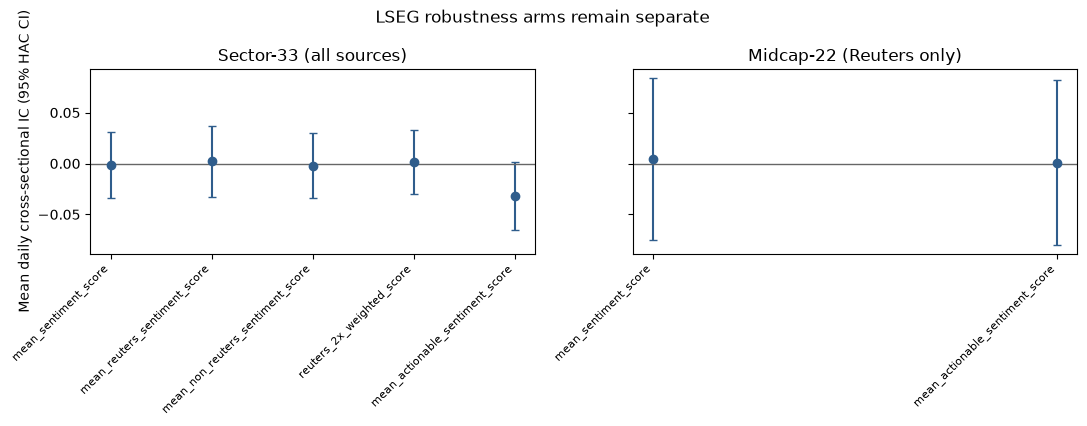

In [4]:
midcap_panel = pd.read_csv(MIDCAP_ROOT / "company_day_panel.csv")
midcap = attach_next_open_returns(midcap_panel, pd.read_csv(MIDCAP_PRICES))
midcap_arms = ("mean_sentiment_score", "mean_actionable_sentiment_score")
midcap_results = lseg_ic_table(
    midcap,
    arms=midcap_arms,
    family="two midcap-22 Reuters-only arms x h1; BH-FDR q=0.05",
)
midcap_results.to_csv(OUTPUT / "midcap22_reuters_only_ic.csv", index=False)
display(midcap_results.round(6))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), sharey=True)
for ax, table, title in [
    (axes[0], sector_results, "Sector-33 (all sources)"),
    (axes[1], midcap_results, "Midcap-22 (Reuters only)"),
]:
    ax.errorbar(
        range(len(table)),
        table["ic"],
        yerr=1.96 * table["se"],
        fmt="o",
        color="#2f5d8c",
        capsize=3,
    )
    ax.axhline(0, color="#666", lw=1)
    ax.set_xticks(range(len(table)))
    ax.set_xticklabels(table["arm"], rotation=45, ha="right", fontsize=8)
    ax.set_title(title)
axes[0].set_ylabel("Mean daily cross-sectional IC (95% HAC CI)")
fig.suptitle("LSEG robustness arms remain separate")
fig.tight_layout()
fig.savefig(OUTPUT / "lseg_nonpooled_ic.png", dpi=150)
plt.show()

## Audit and interpretation boundaries

In [5]:
sector_audit = pd.read_csv(SECTOR_ROOT / "sample_label_template.csv")
try:
    midcap_audit = pd.read_csv(MIDCAP_ROOT / "sample_label_template.csv")
except pd.errors.EmptyDataError:
    midcap_audit = pd.DataFrame()


def labelled_rows(audit: pd.DataFrame) -> int:
    manual_columns = [c for c in audit.columns if c.startswith("manual_")]
    if audit.empty or not manual_columns:
        return 0
    return int(audit[manual_columns].fillna("").astype(bool).any(axis=1).sum())


audit_status = pd.DataFrame(
    [
        {
            "regime": "sector33",
            "audit_rows": len(sector_audit),
            "manual_labels_present": labelled_rows(sector_audit),
        },
        {
            "regime": "midcap22",
            "audit_rows": len(midcap_audit),
            "manual_labels_present": labelled_rows(midcap_audit),
        },
    ]
)
audit_status["status"] = audit_status["manual_labels_present"].map(lambda n: "COMPLETE" if n > 0 else "BLOCKED_PENDING_HUMAN_LABELS")
audit_status.to_csv(OUTPUT / "lseg_taxonomy_audit_status.csv", index=False)
display(audit_status)

manifest = {
    "status": "NON_POOLED_ROBUSTNESS",
    "sector33_family": SECTOR_FAMILY,
    "midcap22_family": "two Reuters-only arms x h1; BH-FDR q=0.05",
    "publisher_weight": "Reuters=2, all unresolved other sources=1; declared ex ante",
    "target": "raw open-to-next-open return",
    "eligibility": "headline_count > 0; identical firm-days within each regime",
    "mapping": "date-only news to first strictly later session",
    "limitations": [
        "LSEG target is not market-adjusted and is not numerically pooled with FNSPID",
        "sector-33 is a short 2025-2026 snapshot",
        "midcap-22 contains Reuters only, so publisher weighting is not identified",
        "opaque non-Reuters codes cannot be responsibly split into aggregator/syndicator/promotional tiers",
        "taxonomy audit templates contain no human labels",
    ],
}
(OUTPUT / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))

,regime,audit_rows,manual_labels_present,status
0,sector33,2000,0,BLOCKED_PENDING_HUMAN_LABELS
1,midcap22,0,0,BLOCKED_PENDING_HUMAN_LABELS


{
  "status": "NON_POOLED_ROBUSTNESS",
  "sector33_family": "five LSEG sector-33 source/actionability arms x h1; BH-FDR q=0.05",
  "midcap22_family": "two Reuters-only arms x h1; BH-FDR q=0.05",
  "publisher_weight": "Reuters=2, all unresolved other sources=1; declared ex ante",
  "target": "raw open-to-next-open return",
  "eligibility": "headline_count > 0; identical firm-days within each regime",
  "mapping": "date-only news to first strictly later session",
  "limitations": [
    "LSEG target is not market-adjusted and is not numerically pooled with FNSPID",
    "sector-33 is a short 2025-2026 snapshot",
    "midcap-22 contains Reuters only, so publisher weighting is not identified",
    "opaque non-Reuters codes cannot be responsibly split into aggregator/syndicator/promotional tiers",
    "taxonomy audit templates contain no human labels"
  ]
}
